In [66]:
import pandas as pd
from urllib.request import urlretrieve
from collections import Counter
import ast
import os
import tarfile
import matplotlib.pyplot as plt

File already exists!


C:\Users\eloil\AppData\Local\Temp\ipykernel_20128\89007997.py:43: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


         Movie_Type   Count
0             Drama  231347
1            Comedy  127840
2      Romance Film   80237
3          Thriller   77003
4            Action   70634
5      World cinema   60611
6     Crime Fiction   53383
7             Indie   47323
8  Action/Adventure   46382
9         Adventure   40131
File already exists!


C:\Users\eloil\AppData\Local\Temp\ipykernel_20128\89007997.py:43: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


    Number_of_Actors  Movie_Count
0                  0           72
1                  1         8921
2                  2         6699
3                  3         5874
4                  4         5159
..               ...          ...
63                72            1
64                78            1
65                81            1
66                87            1
67               115            1

[68 rows x 2 columns]
File already exists!


C:\Users\eloil\AppData\Local\Temp\ipykernel_20128\3220155330.py:43: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


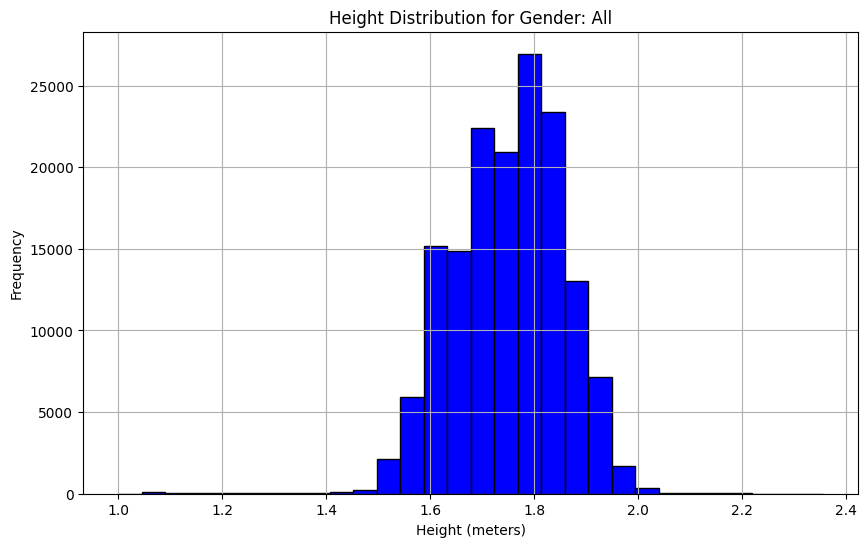

           actor_name actor_gender  actor_height_in_meters
0      Wanda De Jesus            F                   1.620
1  Natasha Henstridge            F                   1.780
2            Ice Cube            M                   1.727
3       Jason Statham            M                   1.750
4         Clea DuVall            F                   1.650


In [67]:
#link for the dataset
data_link = "http://www.cs.cmu.edu/~ark/personas/data/MovieSummaries.tar.gz"

class PEP8:
    def __init__(self, file_link: str, output_file: str='movie_data.tar.gz'):
        """
        First step: Downloads a file from an URL into your hard drive, if it doesn't exist already, if it does,
        then the user gets a warning saying: "File already exists!".
        
        Parameters
        ------------
        file_link: str
            A string containing the link to the file you wish to download.
        output_file: str
            A string containing the name of the output file. The default value is 'movie_data.tar.gz'
            at the location you are running the function.
            
        ------------
        ------------
        Second step: Opens the file, and unzips it, to the working directory, using the output_file variable.

        ------------
        ------------
        Third step: Reads in the tab separated files into pandas dataframes, while naming the columns appropriately. 
        After reading the files into dataframes, it merges the two in order to be able to analyze it simultaneously.

        Returns
        ---------
        .head() of the merged dataframe.
        """
        self.file_link = file_link
        self.output_file = output_file
        self.dataframe = None

        # If file doesn't exist, download it. Else, print a warning message.
        if not os.path.exists(output_file):
            urlretrieve(file_link, filename=output_file)
        else:
            print("File already exists!")
            # Open the tar.gz file
        with tarfile.open(output_file, 'r:gz') as tar:
            # Extract all contents to the current directory
            tar.extractall()
        column_names_for_movies = ['wikipedia_movie_id', 'freebase_movie_id', 'title', 'release_date', 'box_office_revenue', 'runtime_min', 'languages', 'countries', 'genres']
        dataframe_for_movies = pd.read_csv('MovieSummaries\movie.metadata.tsv',sep = '\t', names=column_names_for_movies, header=None)
        
        column_names_for_characters = ['wikipedia_movie_id', 'freebase_movie_id', 'movie_release_date', 'character_name', 'actor_date_of_birth', 'actor_gender', 'actor_height_in_meters', 'actor_ethnicity_freebase_id', 'actor_name', 'actor_age_at_movie_release', 'freebase_character_or_actor_map_id', 'freebase_character_id', 'freebase_actor_id']
        dataframe_for_characters = pd.read_csv('MovieSummaries\character.metadata.tsv',sep = '\t', names=column_names_for_characters, header=None)

        self.dataframe = pd.merge(dataframe_for_characters, dataframe_for_movies, on = ['freebase_movie_id', 'wikipedia_movie_id'], how = 'left')


    def __movie_type__(self, N: int = 10):
        """
        Calculate the N most common types of movies (genres) and return a DataFrame.

        Parameters
        ----------
        N : int, optional
            Number of most common movie types to return. Default is 10.

        Returns
        -------
        pandas.DataFrame
            A DataFrame with two columns: 'Movie_Type' (genre) and 'Count' (number of occurrences).

        Raises
        ------
        TypeError
            If N is not an integer.
        """
        # Check if N is an integer
        if not isinstance(N, int):
            raise TypeError("Variable 'N' is not an integer. Please provide an integer value.")

        # Ensure the DataFrame is available
        if self.dataframe is None:
            raise ValueError("No DataFrame available. Please ensure the DataFrame is generated first.")

        # Extract genres from the 'genres' column
        # The 'genres' column contains dictionary-like strings, so we need to convert them to dictionaries
        self.dataframe['genres'] = self.dataframe['genres'].apply(ast.literal_eval)

        # Flatten the list of genres
        all_genres = [genre for sublist in self.dataframe['genres'].apply(lambda x: list(x.values())) for genre in sublist]

        # Count the occurrences of each genre
        genre_counts = Counter(all_genres)

        # Get the N most common genres
        most_common_genres = genre_counts.most_common(N)

        # Create a DataFrame from the most common genres
        movie_type_df = pd.DataFrame(most_common_genres, columns=['Movie_Type', 'Count'])

        return movie_type_df
    
    # Example usage
    data_link = "http://www.cs.cmu.edu/~ark/personas/data/MovieSummaries.tar.gz"
    processor = PEP8(data_link)

    # Call the __movie_type__ method
    most_common_genres_df = processor.__movie_type__(N=10)  # Get the top 10 most common genres
    print(most_common_genres_df)
    
    def __actor_count__(self):
            """
            Calculate a histogram of "number of actors" vs "movie counts".

            Returns
            -------
            pandas.DataFrame
                A DataFrame with two columns: 'Number_of_Actors' and 'Movie_Count'.
            """
            # Ensure the DataFrame is available
            if self.dataframe is None:
                raise ValueError("No DataFrame available. Please ensure the DataFrame is generated first.")

            # Group by movie using 'wikipedia_movie_id' as the unique identifier for each movie
            movie_actor_counts = self.dataframe.groupby('wikipedia_movie_id')['actor_name'].nunique().reset_index()

            # Rename columns for clarity
            movie_actor_counts.columns = ['wikipedia_movie_id', 'Number_of_Actors']

            # Count how many movies have the same number of actors
            actor_count_histogram = movie_actor_counts['Number_of_Actors'].value_counts().reset_index()

            # Rename columns for clarity
            actor_count_histogram.columns = ['Number_of_Actors', 'Movie_Count']

            # Sort by 'Number_of_Actors' for better readability
            actor_count_histogram = actor_count_histogram.sort_values(by='Number_of_Actors').reset_index(drop=True)

            return actor_count_histogram
    
    # Example usage
    data_link = "http://www.cs.cmu.edu/~ark/personas/data/MovieSummaries.tar.gz"
    processor = PEP8(data_link)

    # Call the __actor_count__ method
    actor_count_histogram = processor.__actor_count__()

    # Print the result
    print(actor_count_histogram)
                    

    def __actor_distributions__(self, gender: str, max_height: float, min_height: float, plot: bool = False):
        """
        Filter actors based on gender and height, and optionally plot the height distribution.

        Parameters
        ----------
        gender : str
            The gender to filter by. Accepts "All" or specific values from the dataset.
        max_height : float
            The maximum height to include in the distribution.
        min_height : float
            The minimum height to include in the distribution.
        plot : bool, optional
            If True, plot the height distribution. Default is False.

        Returns
        -------
        pandas.DataFrame
            A DataFrame containing the filtered actors.

        Raises
        ------
        TypeError
            If gender is not a string or heights are not numerical.
        ValueError
            If gender is not "All" or a valid value in the dataset, or if heights are invalid.
        """
        # Input validation
        if not isinstance(gender, str):
            raise TypeError("The 'gender' parameter must be a string.")
        if not isinstance(max_height, (float, int)) or not isinstance(min_height, (float, int)):
            raise TypeError("The 'max_height' and 'min_height' parameters must be numerical values.")
        if max_height < min_height:
            raise ValueError("'max_height' must be greater than or equal to 'min_height'.")

        # Check if gender is valid
        valid_genders = ['All'] + self.dataframe['actor_gender'].dropna().unique().tolist()
        if gender not in valid_genders:
            raise ValueError(f"Invalid gender. Accepted values are: {valid_genders}")

        # Filter by gender
        if gender == "All":
            filtered_data = self.dataframe
        else:
            filtered_data = self.dataframe[self.dataframe['actor_gender'] == gender]

        # Filter by height
        filtered_data = filtered_data[
            (filtered_data['actor_height_in_meters'] >= min_height) &
            (filtered_data['actor_height_in_meters'] <= max_height)
        ]

        # Check if heights are within a reasonable range
        if (filtered_data['actor_height_in_meters'].min() < 0.5) or (filtered_data['actor_height_in_meters'].max() > 3.0):
            print("Warning: Some heights are outside the reasonable range (0.5 to 3.0 meters).")

        # Plot the height distribution if requested
        if plot:
            plt.figure(figsize=(10, 6))
            plt.hist(filtered_data['actor_height_in_meters'].dropna(), bins=30, color='blue', edgecolor='black')
            plt.title(f'Height Distribution for Gender: {gender}')
            plt.xlabel('Height (meters)')
            plt.ylabel('Frequency')
            plt.grid(True)
            plt.show()

        return filtered_data
    
# Example usage
data_link = "http://www.cs.cmu.edu/~ark/personas/data/MovieSummaries.tar.gz"
processor = PEP8(data_link)

# Call the __actor_distributions__ method
filtered_data = processor.__actor_distributions__(gender="All", max_height=2.5, min_height=1.0, plot=True)

# Print the filtered data
print(filtered_data[['actor_name', 'actor_gender', 'actor_height_in_meters']].head())
    




### Key Observations
Most Common Genre:
- Drama is the most common genre with 231,347 occurrences.

Other Popular Genres:
- Comedy (127,840) and Romance Film (80,237) are the second and third most common genres, respectively.

Action and Thriller:
- Action (70,634) and Thriller (77,003) are also highly represented, reflecting their popularity in film production.

Niche Genres:
- Genres like World cinema (60,611), Crime Fiction (53,383), and Indie (47,323) have significant but smaller counts, indicating a diverse range of film types.

Adventure Genres:
- Action/Adventure (46,382) and Adventure (40,131) are less common but still notable.

### Key Observations
Movies with 0 Actors:

- 72 movies have 0 actors, likely due to missing or incomplete data in the actor_name column.

Movies with 1 Actor:

- 8,921 movies have 1 actor, making this the most common category.    

Movies with 2 or More Actors:

- The number of movies decreases as the number of actors increases:
- 6,699 movies have 2 actors.
- 5,874 movies have 3 actors.
- 5,159 movies have 4 actors.

Movies with Large Casts:
- A few movies have very large casts (e.g., 72, 78, 81, 87, and 115 actors), likely due to ensemble casts or many minor characters.

### Key Observations:

Gender Filtering:
- The dataset was filtered to include actors of the specified gender ("All" in this case).

Height Filtering:
- Only actors with heights between 1.0 and 2.5 meters were included.

Height Distribution:
- The histogram shows the distribution of actor heights within the specified range.
- A warning is displayed if any heights are outside the reasonable range (0.5 to 3.0 meters).

Filtered Data:
- The returned DataFrame contains the filtered actors, including their names, genders, and height

In [64]:
PEP8.__init__(data_link, output_file='movie.tar.gz')

TypeError: PEP8.__init__() missing 1 required positional argument: 'file_link'